# Bell spaceship paradox

In some inertial rest frame, two spaceships are at rest and aligned in the same direction. They are connected by a taut string. At some time in the rest frame, they both turn on their thrusters, after which both ships undergo a constant proper acceleration in the same direction. Does the string break?

To help visualize the situation, let's plot the worldlines of the spaceships in the rest frame. The position $x$ of a particle under a constant proper acceleration $g$ with initial conditions $x = x_0$ and $\dot x = 0$ at time $t = 0$ is:

$$
x = \frac{c^2}{g} \Bigl(
    \sqrt{1 + (g t / c)^2} - 1
\Bigr) + x_0
$$

I won't show the derivation for the above equation because it is fairly long. But [Wikipedia](https://en.wikipedia.org/wiki/Acceleration_(special_relativity)#:~:text=The%20constant%2C%20longitudinal%20proper%20acceleration) backs me up on it.

Getting an equation for $\dot x$ from this is simple enough, so let's do it.

$$
\dot x
= \frac{d}{dt} x
= \frac{c^2}{g} \frac{d}{dt} \sqrt{1 + (g t / c)^2}
= \frac{c^2}{2 g} \frac{1}{\sqrt{1 + (g t / c)^2}} \frac{d}{dt}(gt / c)^2
$$

$$
= \frac{c^2 }{2 g \sqrt{1 + (g t / c)^2}} \frac{2 g^2 t}{c^2}
= \frac{g t}{\sqrt{1 + (g t / c)^2}}
$$

Let's initialize one of the spaceships to $x=0$ and the other to $x=L$, so the string initially has length $L$. Then the positions and velocities of the spaceships over time in the rest frame are:

$$
x_1(t) = \frac{c^2}{g} \Bigl(
    \sqrt{1 + (g t / c)^2} - 1
\Bigr)
\quad\quad
x_2(t) = \frac{c^2}{g} \Bigl(
    \sqrt{1 + (g t / c)^2} - 1
\Bigr) + L
$$

$$
\dot x_1(t) = \dot x_2(t) = \frac{gt}{\sqrt{1 + (gt / c)^2}}
$$

Let's plot these worldlines for $c = 1$, $g = 0.1$, $L = 2$.

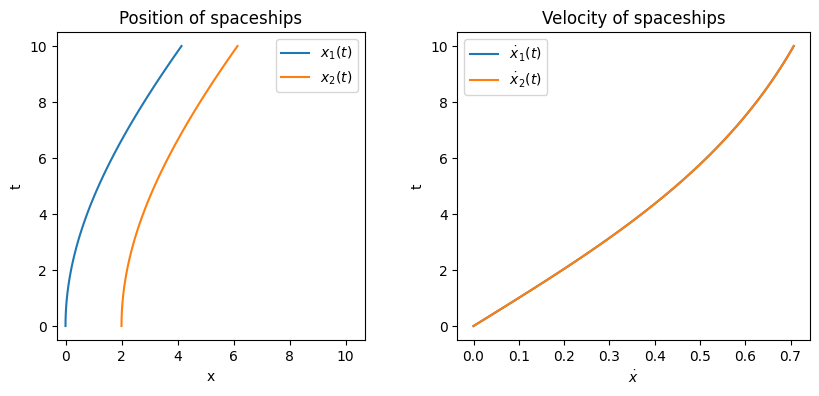

In [57]:
import numpy as np
import matplotlib.pyplot as plt

g = 0.1
L = 2
c = 1

t = np.linspace(0, 10)

def calc_x1(t, g, c):
    return (c**2 / g) * ((1 + (g * t / c)**2)**0.5 - 1)

def calc_x2(t, g, c, L):
    return calc_x1(t, g, c) + L

def calc_v(t, g, c):
    return g * t / (1 + (g * t / c)**2)**0.5

x1 = calc_x1(t, g, c)
x2 = calc_x2(t, g, c, L)

v1 = calc_v(t, g, c)
v2 = calc_v(t, g, c)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x1, t, label='$x_1(t)$')
axes[0].plot(x2, t, label='$x_2(t)$')
axes[0].axis('square')
axes[0].set_title('Position of spaceships')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
axes[0].legend()

axes[1].plot(v1, t, label='$ \\dot x_1(t)$')
axes[1].plot(v2, t, label='$ \\dot x_2(t)$')
axes[1].set_title('Velocity of spaceships')
axes[1].set_xlabel('$\\dot x$')
axes[1].set_ylabel('t')
axes[1].legend()

plt.show()

In the rest frame, the two spaceships always maintain the same measured distance from each other, $x_2(t) - x_1(t) = L$, at all times. One might be tempted to say that because of this, the string need not break, as long as the acceleration of the spaceships is small enough for the string to withstand.

However, the distance between the spaceships measured in an inertial reference frame is not the only detail we need to know. We also need to know the proper distance between the spaceships.

Consider for a moment a different scenario, where we have a rigid pole sitting at rest. In a frame that is moving with velocity $v$ in the axial direction of the pole, we will measure the pole's length to be contracted. But we know that the pole doesn't actually get shorter. The "actual length of the pole" is its proper length, in the frame where it is at rest, and that stays constant. If its proper length is $L_p$ and the length we measure in our moving frame is $L$, then:

$$
L = L_p \sqrt{1 - (v/c)^2}
$$

Where $L_p$ is constant.

In the case of the two spaceships, we showed that the distance $L$ between them measured in the rest frame is held constant, which means that the proper distance $L_p$ between them has to change as they accelerate and $v$ increases. The proper distance between the spaceships over time is then:

$$
L_p(t) = \frac{L}{\sqrt{1 - \Bigl(v(t) /c\Bigr)^2}}
$$

This blows up toward infinity as time progresses.

$$
\lim_{t\rightarrow \infty} L_p(t)
= \lim_{v\rightarrow c}\frac{L}{\sqrt{1 - \Bigl(v /c\Bigr)^2}}
= \lim_{\alpha\rightarrow 0}\frac{L}{\alpha}
= \infty
$$

As the spaceships accelerate, the proper distance between them increases unbounded, so it seems that the string has to break eventually.

It seems that this should be true even if the string does not accelerate uniformly. In reality, parts of the string that are further away from the spaceships will take longer to begin to be accelerated, since all interactions are limited by the speed of light. But the fact is that no matter how exactly the string accelerates, the two ends are tied to the two spaceships, and the proper distance between the ends increases forever, so at some point the string will be stretched to its breaking point.

But nevertheless, things in relativity are not always so intuitive. Maybe the the fact that different parts of the string are moving at different velocities might affect whether the string breaks or not. So let's explicitly check the case of a non-uniformly accelerating string. Since the two ends of the string would begin to move before any other part, the leading end (at spaceship 2) will stretch out, at least by a little bit. The following end will either bunch up in front of spaceship 1, or it will overtake itself so that part of the string trails behind spaceship 1.

We can add up the infinitesimal proper distances of each little segment of string between the two spaceships to find the total proper distance of this nonuniformly accelerating string that lies between the two spaceships. We will neglect to incorporate the proper length of any string that is bunched up in front of or trailing behind spaceship 1, but we'll see that that doesn't matter because the proper distance of the portion that lies between the ships will already be greater than $L$.

From the perspective of the rest frame, each little segment of string that falls between the two spaceships may travel at a different velocity, $v_s(x, t) \ge 0$. The infinitesimal proper length of each segment is:

$$
d L_p(x, t)
= \frac{d x}{\sqrt{1 - \Bigl(v_s(x, t) / c\Bigr)^2}}
$$

Adding up all the little pieces, we get:

$$
L_p(t)
= \int_{x_1(t)}^{x_2(t)} d L_p(x, t)
= \int_{x_1(t)}^{x_1(t) + L} \frac{d x}{\sqrt{1 - \Bigl(v_s(x, t) / c\Bigr)^2}}
$$

At time $t\le0$, the string is at rest, so $v_s = 0$ everywhere, and the proper length of the string is:

$$
L_p(t\le 0)
= \int_{x_1(t\le 0)}^{x_1(t\le 0) + L} \frac{d x}{\sqrt{1 - \Bigl(0 / c\Bigr)^2}}
= \int_{0}^{L} d x
= L
$$

Of course we already knew that.

After a very long time, if the string were to stay in tact, the spaceships, and thus the entire string, would end up reaching near the speed of light.

$$
\lim_{t\rightarrow \infty} v_s(x ,t) = c
$$

So in the limit as the string approaches the speed of light, the proper length of the portion of string between the two spaceships approaches:

$$
\lim_{t \rightarrow \infty} L_p(t)
= \lim_{t\rightarrow\infty}
\int_{x_1(t)}^{x_1(t) + L} \frac{d x}{\sqrt{1 - \Bigl(v_s(x, t) / c\Bigr)^2}}
$$

$$
= \lim_{t\rightarrow\infty, v_s\rightarrow c}
\int_{x_1(t)}^{x_1(t) + L} \frac{d x}{\sqrt{1 - \Bigl(v_s/ c\Bigr)^2}}
= \lim_{t\rightarrow\infty, v_s\rightarrow c}
\frac{1}{\sqrt{1 - \Bigl(v_s/ c\Bigr)^2}}
\int_{x_1(t)}^{x_1(t) + L} dx
$$

$$
= \lim_{v_s\rightarrow c}
\frac{1}{\sqrt{1 - \Bigl(v_s/ c\Bigr)^2}}
L
= \lim_{\alpha\rightarrow 0}
\frac{1}{\alpha} L
= \infty
$$

Therefore, even a nonuniformly accelerating string's proper length increases unbounded as time progresses, so it will have to break at some point.

To have any chance of keeping the string in tact, the spaceships cannot accelerate uniformly. Instead, they would have to accelerate in such a way that the proper distance between them either remains constant or shrinks. To accomplish that, the distance between them would have to shrink when measured from the rest frame, in the same way that the length of a rigid pole would contract as it accelerates.